<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">

by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia


# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [10]:
DATA_DIR = 'Data' 

df = pd.read_csv("../Dataset/Merged Data/merged.csv")
pd.set_option('display.max_columns', None)
df.shape

(113425, 47)

# **Section 1: Business Explanation**

This section frames the project before any modeling begins: who Olist is, what problem we are solving, for who, how we will approach it, and how we will know it worked. Every claim below is grounded in the preliminary EDA already performed on this dataset not assumptions.


## **1.1 Business Context**

Olist is the largest department store in Brazilian online marketplaces. It does not sell its own products, instead, it operates a multi seller marketplace platform that connects small to medium sized Brazilian businesses to major sales platforms without those sellers needing to build their own e-commerce structure.

Because Olist itself does not control manufacturing or (in most cases) directly control the carrier's performance, its reputation depends entirely on the combined performance of thousands of independent sellers (3,095 in this dataset) and its logistics network, spread across all 27 Brazilian states. A bad experience with any one seller or shipping route reflects on the Olist platform as a whole, since customers experience Olist as one marketplace, not as individual sellers.

This is why **customer satisfaction** functions as Olist's core success metric. Low satisfaction reflected in low review scores can damage a seller's reputation and sales performance, which in turn threatens the health of Olist's whole multi-seller ecosystem. High satisfaction, conversely, drives customer retention and repeat purchases, supporting the platform's long-term sustainability. A satisfied shopper leave positive reviews, which builds trust and drives sales for the platform's independent merchants.

Below are preliminary analysis results that shows that the delivery-satisfaction relationship is real and worth building a project around. The deeper factor analysis (which sellers, regions, product types, and timing windows carry the highest risk) happens in the EDA section using `is_late` as the foundation.

In [11]:
delivered = df[
    (df['order_status'] == 'delivered') &
    df['order_delivered_customer_date'].notna() &
    df['review_score'].notna()
].copy()

delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])

delivered['is_late'] = (
    delivered['order_delivered_customer_date'].dt.normalize() >
    delivered['order_estimated_delivery_date'].dt.normalize()
)
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

print(f"Orders analyzed: {len(delivered):,}")
print(f"Late delivery rate: {delivered['is_late'].mean():.1%}")
print()
print(delivered.groupby('is_late')['review_score'].agg(['mean', 'median', 'count']))

Orders analyzed: 109,362
Late delivery rate: 6.5%

             mean  median   count
is_late                          
False    4.208293     5.0  102279
True     2.256106     1.0    7083


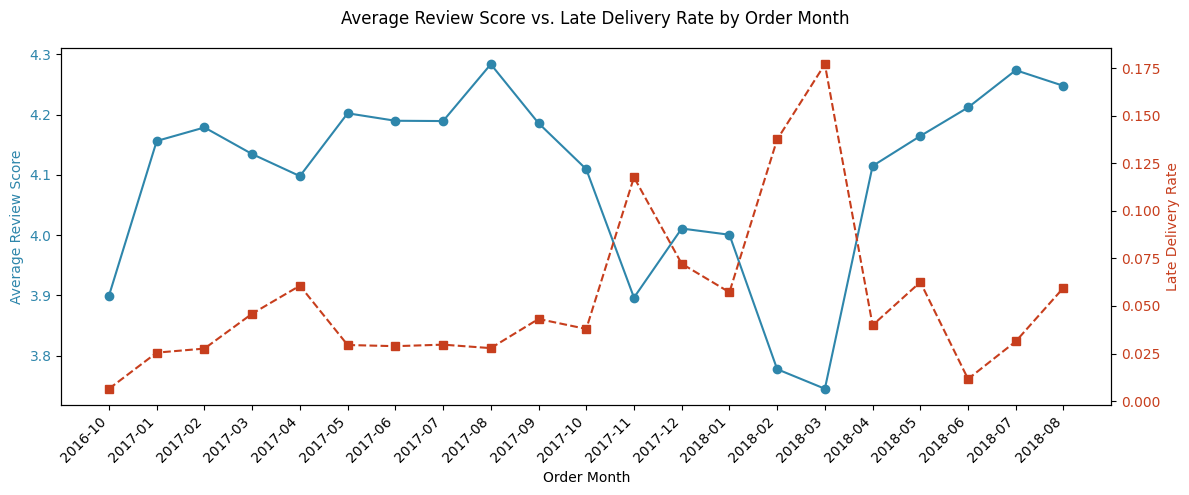

Correlation (monthly late rate vs. monthly avg review score): -0.77


In [12]:
monthly = (
    delivered
    .assign(month=delivered['order_purchase_timestamp'].dt.to_period('M').astype(str))
    .groupby('month')
    .agg(avg_review=('review_score', 'mean'), late_rate=('is_late', 'mean'), n_orders=('review_score', 'size'))
    .reset_index()
)
monthly = monthly[monthly['n_orders'] > 100]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly['month'], monthly['avg_review'], color='#2E86AB', marker='o', label='Avg. Review Score')
ax1.set_ylabel('Average Review Score', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_xlabel('Order Month')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['late_rate'], color='#C73E1D', marker='s', linestyle='--', label='Late Delivery Rate')
ax2.set_ylabel('Late Delivery Rate', color='#C73E1D')
ax2.tick_params(axis='y', labelcolor='#C73E1D')

fig.suptitle('Average Review Score vs. Late Delivery Rate by Order Month')
fig.tight_layout()
plt.show()

print(f"Correlation (monthly late rate vs. monthly avg review score): {monthly['avg_review'].corr(monthly['late_rate']):.2f}")


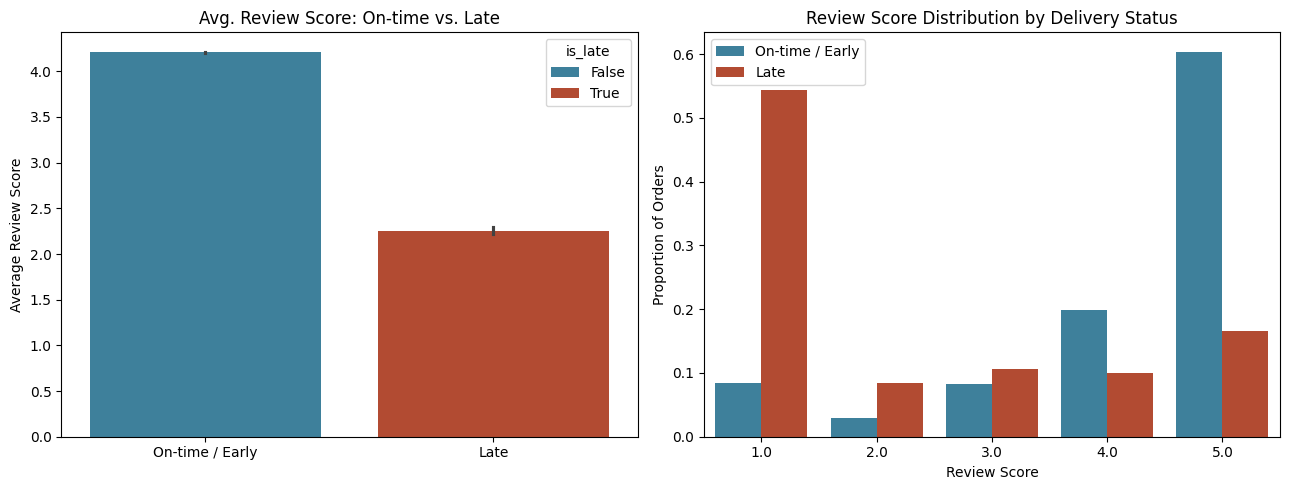

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=delivered, x='is_late', y='review_score', ax=axes[0], hue='is_late', palette=['#2E86AB', '#C73E1D'])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['On-time / Early', 'Late'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Review Score')
axes[0].set_title('Avg. Review Score: On-time vs. Late')

score_dist = (
    delivered
    .groupby('is_late')['review_score']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)
score_dist['is_late'] = score_dist['is_late'].map({False: 'On-time / Early', True: 'Late'})

sns.barplot(data=score_dist, x='review_score', y='proportion', hue='is_late', ax=axes[1], palette=['#2E86AB', '#C73E1D'])
axes[1].set_title('Review Score Distribution by Delivery Status')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Proportion of Orders')
axes[1].legend(title='')

plt.tight_layout()
plt.show()


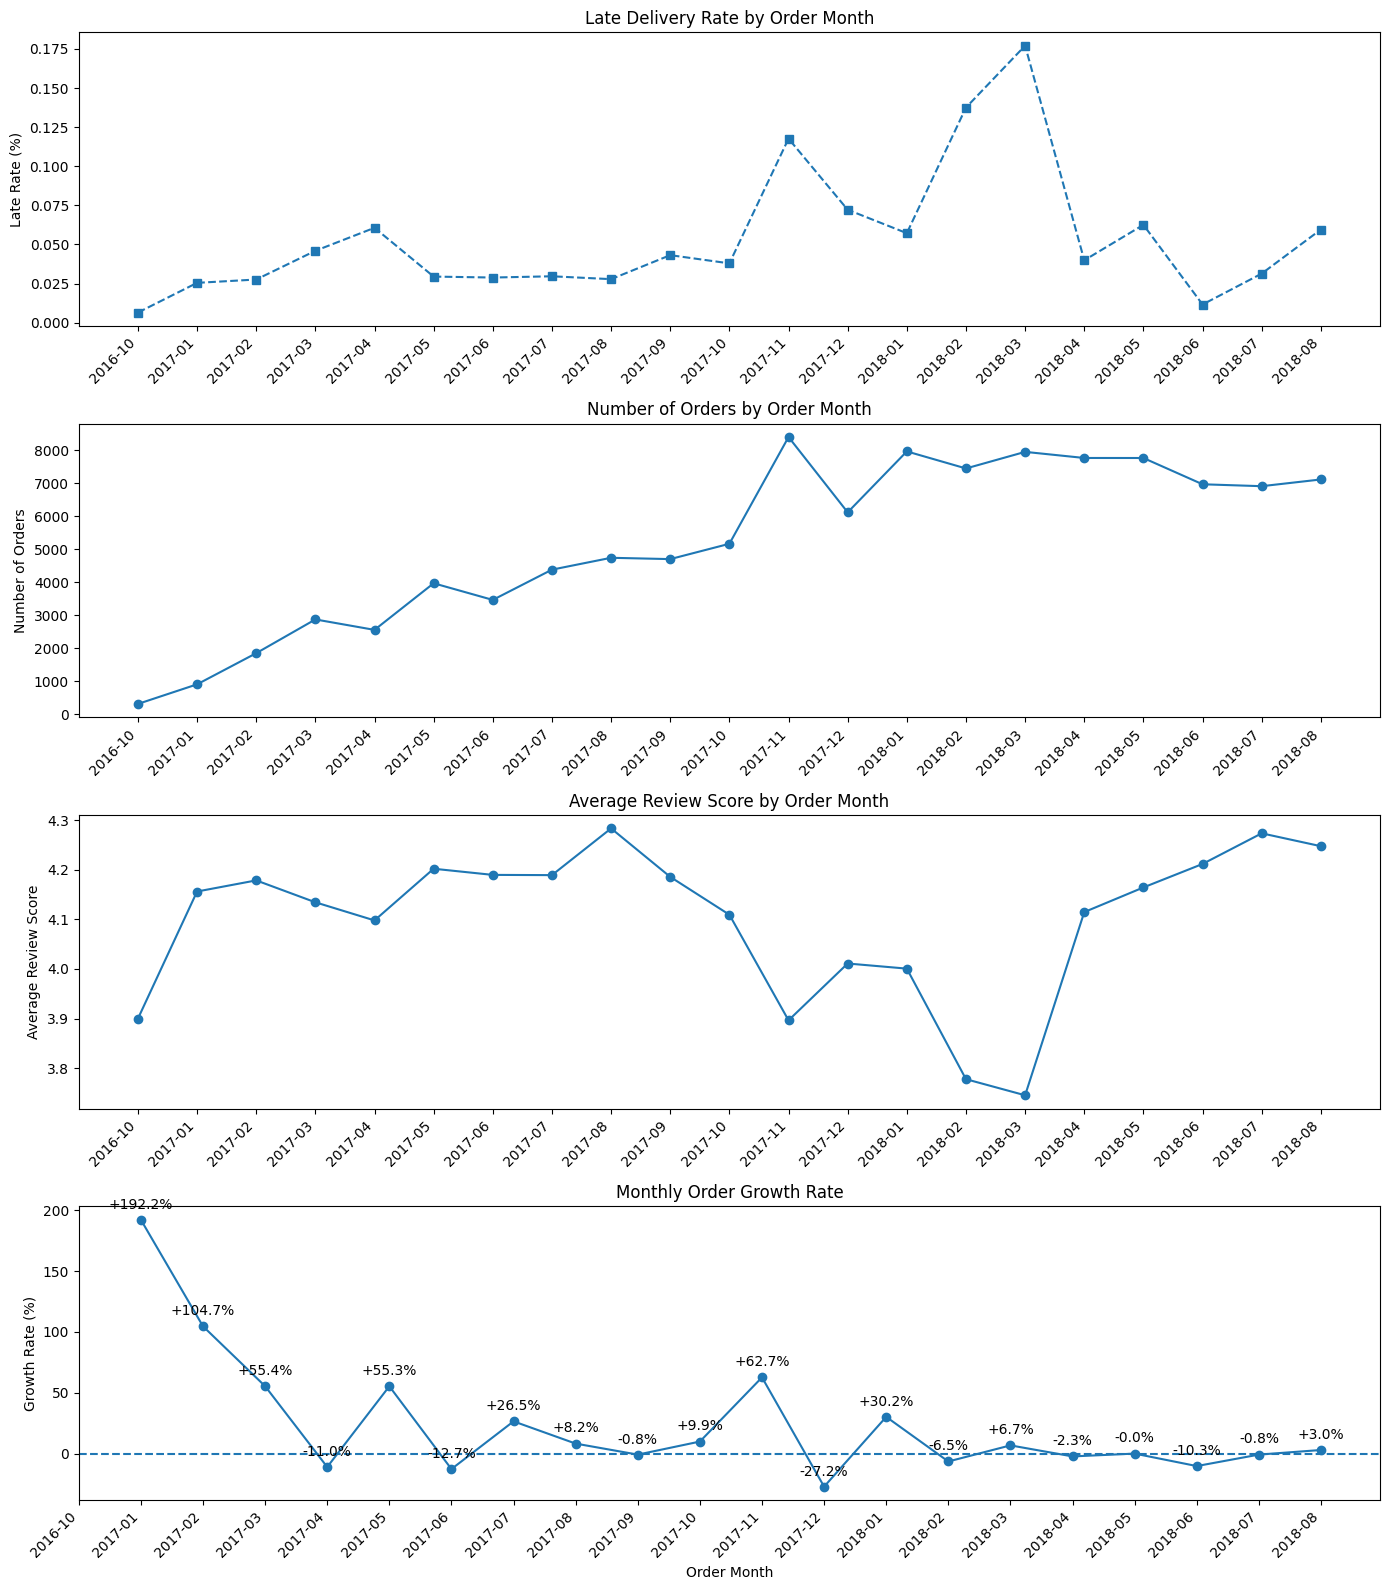

In [14]:
monthly["order_growth_rate"] = monthly["n_orders"].pct_change() * 100

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

x = range(len(monthly))
labels = monthly["month"]

# 1. Late Delivery Rate
axes[0].plot(
    x,
    monthly["late_rate"],
    marker="s",
    linestyle="--"
)
axes[0].set_title("Late Delivery Rate by Order Month")
axes[0].set_ylabel("Late Rate (%)")

# 2. Number of Orders
axes[1].plot(
    x,
    monthly["n_orders"],
    marker="o"
)
axes[1].set_title("Number of Orders by Order Month")
axes[1].set_ylabel("Number of Orders")

# 3. Average Review Score
axes[2].plot(
    x,
    monthly["avg_review"],
    marker="o"
)
axes[2].set_title("Average Review Score by Order Month")
axes[2].set_ylabel("Average Review Score")

# 4. Order Growth Rate
axes[3].plot(
    x,
    monthly["order_growth_rate"],
    marker="o"
)
axes[3].axhline(0, linestyle="--")
axes[3].set_title("Monthly Order Growth Rate")
axes[3].set_ylabel("Growth Rate (%)")
axes[3].set_xlabel("Order Month")

# Growth rate labels
for i, y in enumerate(monthly["order_growth_rate"]):
    if pd.notna(y):
        axes[3].annotate(
            f"{y:+.1f}%",
            (i, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center"
        )

# X-axis labels
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

plt.tight_layout()
plt.show()

In [15]:
from scipy import stats

on_time_scores = delivered.loc[~delivered['is_late'], 'review_score']
late_scores = delivered.loc[delivered['is_late'], 'review_score']

t_stat, p_val = stats.ttest_ind(on_time_scores, late_scores, equal_var=False)
print(f"Welch's t-test (on-time vs late review scores): t={t_stat:.2f}, p={p_val:.2e}")

Welch's t-test (on-time vs late review scores): t=102.38, p=0.00e+00


These analysis indicates that delivery performance and review scores are consistently linked. Late deliveries make up a small share of completed orders (6.5%), yet they carry a disproportionate share of dissatisfaction: on-time orders average a review score of 4.21 against 2.26 for late ones, a gap confirmed statistically significant by the Welch's t-test above (p < 0.001) rather than assumed from the raw numbers alone. A large share of late orders result in the lowest rating (1-star). This pattern is consistent across the dataset's full timespan (month-over-month, correlation of -0.77 between monthly late rate and monthly average review score), not just in isolated batches, meaning it's a structural relationship, not noise.

### **1.1.1 Is a 4.01/5 Average Rating Actually a Problem for Olist?**

Before treating customer satisfaction as a priority, it is necessary to determine whether Olist's 4.01/5 average review score represents a true operational weakness or merely an acceptable industry baseline. Evaluating this requires separating two distinct issues: whether 4.01 is objectively low compared to e-commerce benchmarks, and whether it negatively impacts Olist's financial performance despite the platform's ongoing order growth during the period analyzed.

PowerReviews [1] analyzed over 25.4 million product pages across more than 3,600 retailer and brand sites, found the average e-commerce product rating sits around 4.5 stars. Separately, research from Northwestern University's Spiegel Research Center [5] found that shoppers are most likely to purchase from listings rated between 4.2 and 4.5, then conversion starts to decline again as ratings approach a suspiciously perfect 5.0. Olist's 4.01 sits just below this commonly observed range. This means that this gap indicates that Olist is losing potential sales where customers visiting the platform are less likely to finalize their purchases compared to competitors operating within the industry standard.

Though Olist's growth have not actualy stalled from 2016-2018 (can be shown directly from the dataset itself). Monthly order volume grew from just 324 orders in October 2016 to over 7,000 orders per month by early-to-mid 2018 (the single-digit counts at the very start and end of the range are incomplete partial months at the edge of data collection, not real activity) roughly a 20x increase while the average review score held steady around 4.0-4.2. 

This still matters because growth and efficiency are two different metrics. A platform can continuously scale its order volume while continuing to lose measurable value to a fixable, quantifiable inefficiency

- The preliminary analysis shows that within Olist's own data, late deliverey orders average a review score of 2.26 whereas on-time deliveries averages 4.21.

- Unlike whatever combination of factors actually drove that 20x order-volume growth (which this dataset cannot fully explain, since it likely involves seller acquisition, marketing, or market expansion outside what these tables record), late-delivery risk is something operations can directly act on using data already being collected.

- Olist's order volume grew substantially throughout the period, but its monthly growth rate was not consistently increasing. For example, order growth reached +62.2% in November 2017, before dropping to -27.2% in December 2017. During this same peak period, the higher order volume also coincided with a higher rate of late deliveries and lower review scores. This highlights how late deliveries can affect customer experience as Olist continues to scale.

- 6.5% of the roughly 100K orders in this dataset is already over 6,500 damaged customer experiences, and that absolute count grew right alongside the order volume itself across 2016-2018.

Improving Olist’s score from 4.01 toward 4.5 offers direct financial benefits beyond the initial conversion gains. Michael Luca's Harvard Business School study of Yelp [6] found that a one-star increase in rating led to a 5-9% increase in revenue. Though this study is about local businesses on Yelp and not an e-commerce marketplace, the underlying mechanism applies universally. For instance, when buyers cannot physically inspect product quality prior to purchase, aggregated historical ratings serve as the primary signal of trust. For Olist’s customers, star ratings serve as a visible shortcut to judge a seller's trustworthiness. Additionally, a better rating is expected to increase sales volume, though the exact impact will depend on e-commerce market trends.

What does not necessarily transfer is the exact size of the effect. The 5-9% figure came from a market where competition is often local and geographically limited (choosing near restaurants), whereas Olist customers can typically choose among thousands of listings, a difference that plausibly changes the magnitude of the effect even if its direction holds. This is why the earlier PowerReviews [3] and Spiegel Research Center [5] findings matter alongside Luca's study [6] wven though it is in a different domain but proves the relationship is causal not just coincidental.

This relationship directly reflects Olist’s business model, which relies on taking a commission fee from each merchant sale. Higher platform ratings improve conversion rates on seller listings, leading to more completed transactions and higher total revenue for Olist. Ultimately, resolving the delivery delays that drive negative reviews creates operational efficiency by lowering costs associated with refunds, customer service inquiries, and order cancellations.

Independent research using this same Olist dataset has reached a similar conclusion: delivery duration is repeatedly identified as one of the primary predictors of customer satisfaction (Gopinadh et al., 2026; Wangkiat & Polprasert, 2023), and separate work has specifically highlighted shipping-related operational factors as a key determinant of e-commerce satisfaction (Brazilian Journal of Technology, 2024). Our own analysis above reaches the same conclusion independently, which strengthens confidence that this is a real, reproducible pattern rather than an artifact of how this project happened to slice the data.

## **1.2 Problem Statement**
Late deliveries make up only 6.5% of Olist's orders, yet they are associated with a review score that collapses from 4.21 to 2.26 so how can a machine learning model predict, early enough for Operations to act, which orders are at risk of late delivery, so Olist can intervene proactively and protect the customer satisfaction that late delivery reliably damages?

## **1.3 Key Objectives**

1. **Identify and characterize the factors behind late delivery**: analyze order, seller, customer, product, and logistics-related factors (e.g. which sellers, regions, shipping distances, or product categories show elevated late-delivery rates) so the problem can be localized and explained, not treated as random noise.

2. **Quantify the satisfaction cost of lateness**: translate "late" into a measurable drop in review score (and, by extension, into churn risk), so the business impact is stated in evidence rather than left anecdotal.

3. **Build a predictive risk model usable within a real intervention window**: develop a classification model that flags an order's late-delivery risk at, or shortly after, order approval (not just after the fact), so the prediction arrives early enough for operations to realistically act on it.

4. **Establish an evaluation framework aligned with business cost, not just statistical accuracy**: given the class imbalance in late vs. on-time orders, a naive "always predict on-time" model can score deceptively high on accuracy while catching zero real risk. (Objectives around metric selection and success criteria exist specifically to avoid that trap)

5. **Translate findings into concrete, actionable levers for Operations**: point toward actions Olist can actually take (seller SLAs, carrier choice, adding buffer to estimated delivery dates, proactive customer communication on at-risk orders), since delivery delay is largely a supply-side problem the platform can influence.

**Key stakeholder: Operations & Logistics Team**. These findings and this model are built for them to help them identify the drivers
behind delays, detect high-risk orders earlier, and prioritize proactive action to protect delivery performance and customer satisfaction.


## **1.4 Analytical Approach**

The analytical approach for this project consists of several systematic stages:

| **Stage** | **Implementation** |
|---|---|
| `Data Understanding` | Understand the structure and characteristics of the dataset, while identifying potential data issues such as inconsistencies, missing values, and anomalies. |
| `Exploratory Data Analysis (EDA)` | Conduct descriptive analysis and data visualization to identify patterns, relationships between variables, and factors associated with late delivery. |
| `Data Preprocessing` | Prepare and clean the data by handling missing values, outliers, categorical variables, and other data quality issues before modeling. |
| `Feature Engineering` | Create relevant features and transform existing variables to better represent the factors that may contribute to late delivery and improve model performance. |
| `Modeling` | Experiment with several machine learning algorithms to develop a model that can predict the likelihood of an order experiencing late delivery. |
| `Model Evaluation` | Evaluate model performance using metrics that are appropriate for the prediction objective and aligned with the business problem. |
| `Business Recommendation` | Translate the EDA findings and model results into actionable insights that can help Olist identify high-risk orders and improve delivery performance. |

## **1.5 References**

1. Gopinadh, A. V. S. S., Sarma, S. V. S. N., & Radhesyam, G. (2026). Customer satisfaction prediction in online goods delivery through interpretable predictive models and sentiment analysis. In A. Kumar & S. Mozar (Eds.), Proceedings of the 7th International Conference on Communications and Cyber Physical Engineering (ICCCE 2024), Lecture Notes in Electrical Engineering, vol. 1466, pp. 1015-1025. Springer, Singapore. https://doi.org/10.1007/978-981-95-0269-1_114

2. Wangkiat, P., & Polprasert, C. (2023). Machine learning approach to predict e-commerce customer satisfaction score. IEEE conference https://ieeexplore.ieee.org/document/10147542/

3.  Mahdjoub Mohammed Bachir, Zohra, F., Laallam Professor, Messaoud Mezati and Djouhri Ahlam (2024). Enhancing Customer Satisfaction using Machine Learning. Brazilian Journal of Technology, 7(4), pp.1–20. doi:10.38152/bjtv7n4-011.

4. PowerReviews. (2022). Ratings & Reviews Benchmarks: Average Rating. Based on an analysis of 25.4M+ product pages across 3,600+ retailer and brand sites.

5. Northwestern University, Spiegel Research Center. How Online Reviews Influence Sales.

6. Luca, M. (2011, rev. 2016). Reviews, reputation, and revenue: The case of Yelp.com. Harvard Business School Working Paper No. 12-016.

7. Hien, N. N., et al. (2024). Customer responses to airline service failure: Perspectives from expectation disconfirmation theory. Journal of Service Theory and Practice, SAGE.

8. (2024). Finding the sweet spots: Optimizing compensation in proactive service recovery. Journal of Consumer Satisfaction, Dissatisfaction and Complaining Behavior.